In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import math

In [43]:
df=pd.read_csv('https://github.com/Rhtyme/ml_uz_book/blob/main/practice_session/Logistic_regression_5_6/diabetes.csv?raw=True')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [44]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [45]:
df = np.array(df, dtype = float)

In [46]:
X = df[:, :8]
Y = df[:, 8:]

In [47]:
X[:10]

array([[6.000e+00, 1.480e+02, 7.200e+01, 3.500e+01, 0.000e+00, 3.360e+01,
        6.270e-01, 5.000e+01],
       [1.000e+00, 8.500e+01, 6.600e+01, 2.900e+01, 0.000e+00, 2.660e+01,
        3.510e-01, 3.100e+01],
       [8.000e+00, 1.830e+02, 6.400e+01, 0.000e+00, 0.000e+00, 2.330e+01,
        6.720e-01, 3.200e+01],
       [1.000e+00, 8.900e+01, 6.600e+01, 2.300e+01, 9.400e+01, 2.810e+01,
        1.670e-01, 2.100e+01],
       [0.000e+00, 1.370e+02, 4.000e+01, 3.500e+01, 1.680e+02, 4.310e+01,
        2.288e+00, 3.300e+01],
       [5.000e+00, 1.160e+02, 7.400e+01, 0.000e+00, 0.000e+00, 2.560e+01,
        2.010e-01, 3.000e+01],
       [3.000e+00, 7.800e+01, 5.000e+01, 3.200e+01, 8.800e+01, 3.100e+01,
        2.480e-01, 2.600e+01],
       [1.000e+01, 1.150e+02, 0.000e+00, 0.000e+00, 0.000e+00, 3.530e+01,
        1.340e-01, 2.900e+01],
       [2.000e+00, 1.970e+02, 7.000e+01, 4.500e+01, 5.430e+02, 3.050e+01,
        1.580e-01, 5.300e+01],
       [8.000e+00, 1.250e+02, 9.600e+01, 0.000e+00, 0.0

In [48]:
def feature_scaling(X):
  avg_array = np.mean(X, 0)
  std_array = np.std(X, 0)
  return np.divide(X - avg_array, std_array)

In [49]:
X = feature_scaling(X)

In [50]:
def add_bias(X):
  B = np.ones((X.shape[0],1))
  return np.hstack((B, X))

X = add_bias(X)

In [67]:
def split(X, Y):
  rows,_ = X.shape
  train_rows = round(rows*0.8)
  test_rows = rows - train_rows
  return X[0:train_rows, :], X[train_rows:, :], Y[0:train_rows, :], Y[train_rows:, :]

X_train, X_test, Y_train, Y_test = split(X, Y)

In [68]:
X_train


array([[ 1.        ,  0.63994726,  0.84832379, ...,  0.20401277,
         0.46849198,  1.4259954 ],
       [ 1.        , -0.84488505, -1.12339636, ..., -0.68442195,
        -0.36506078, -0.19067191],
       [ 1.        ,  1.23388019,  1.94372388, ..., -1.10325546,
         0.60439732, -0.10558415],
       ...,
       [ 1.        , -0.25095213,  1.66204957, ...,  0.1151693 ,
         0.36580794,  0.23476686],
       [ 1.        ,  0.93691372,  1.4742667 , ...,  0.7878413 ,
         0.95171097,  0.57511787],
       [ 1.        ,  0.63994726, -0.49745345, ...,  0.0644016 ,
         1.22654177, -0.61611067]])

In [52]:
A = np.random.rand(X.shape[1], 1)

In [53]:
def logistic_regression_function(X,A):
  Z = np.dot(X, A)
  return 1/(1+np.exp(-Z))

In [58]:
def cost(X,A,Y):
  m=Y.shape[0]
  F_x=logistic_regression_function(X,A)
  cost_=-np.sum(Y*np.log(F_x)+(1-Y)*np.log(1-F_x))/m
  return cost_

In [59]:
epochs = 500
learning_rate = 0.1


In [69]:
def gradient_descent(X_train, X_test, Y_train, Y_test, epochs, learning_rate, A):
  test_costs = []
  train_costs = []
  m_train = Y_train.shape[0]
  m_test = Y_test.shape[0]
  for k in range(epochs):
    F_x = logistic_regression_function(X_train, A)
    A = A - learning_rate*np.dot(X_train.T,(F_x-Y_train))/m_train
    cost_train = cost(X_train, A, Y_train)
    cost_test = cost(X_test, A, Y_test)
    train_costs.append(cost_train)
    test_costs.append(cost_test)
    if k%20 == 0:
      print(f'epoch: {k,cost_train}')
  return A,train_costs,test_costs



In [71]:
A, train_costs, test_costs = gradient_descent(X_train, X_test, Y_train, Y_test, epochs, learning_rate, A)

epoch: (0, np.float64(0.9198863529972815))
epoch: (20, np.float64(0.7444391925255568))
epoch: (40, np.float64(0.6259421787076357))
epoch: (60, np.float64(0.5535841584576091))
epoch: (80, np.float64(0.5137033314856891))
epoch: (100, np.float64(0.493218570728477))
epoch: (120, np.float64(0.482844440862237))
epoch: (140, np.float64(0.47737151218514573))
epoch: (160, np.float64(0.47427765565767666))
epoch: (180, np.float64(0.47240437781228173))
epoch: (200, np.float64(0.4712069489434045))
epoch: (220, np.float64(0.470411473161722))
epoch: (240, np.float64(0.46986882150043147))
epoch: (260, np.float64(0.4694917459987186))
epoch: (280, np.float64(0.469226236288485))
epoch: (300, np.float64(0.46903743873270026))
epoch: (320, np.float64(0.4689021759018652))
epoch: (340, np.float64(0.46880469309247713))
epoch: (360, np.float64(0.4687341040954812))
epoch: (380, np.float64(0.46868279152397974))
epoch: (400, np.float64(0.46864537235973586))
epoch: (420, np.float64(0.46861801234533923))
epoch: (440

In [87]:
def plot_cost(train_costs,test_costs,epochs):
  plt.xlabel('Epochs')
  plt.ylabel('Cost')
  plt.plot(epochs,train_costs,'m',linewidth=1,color='g',label='mashqdagi xatolik')
  plt.plot(epochs,test_costs,'m',linewidth=1,color='b',label='testdagi xatolik')
  plt.legend(loc='upper right')
  plt.show()

In [88]:


n_epochs = np.arange(1,epochs+1)

/tmp/ipython-input-3366917329.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "m" (-> color=(0.75, 0.0, 0.75, 1)). The keyword argument will take precedence.
  plt.plot(epochs,train_costs,'m',linewidth=1,color='g',label='mashqdagi xatolik')
/tmp/ipython-input-3366917329.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "m" (-> color=(0.75, 0.0, 0.75, 1)). The keyword argument will take precedence.
  plt.plot(epochs,test_costs,'m',linewidth=1,color='b',label='testdagi xatolik')


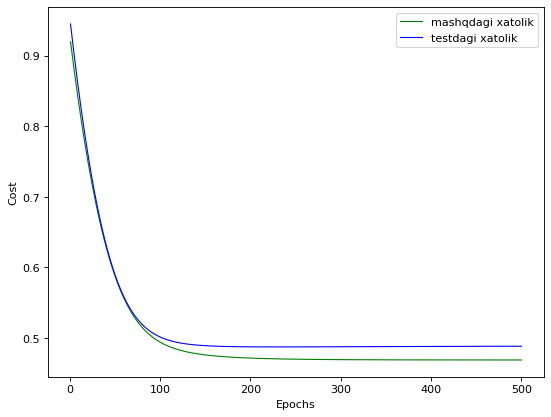

In [89]:

figure(figsize=(8,6),dpi=80)

plot_cost(train_costs,test_costs,n_epochs)

In [90]:
test_predictions = logistic_regression_function(X_test, A)
test_predictions[:20]

array([[0.74844066],
       [0.08805634],
       [0.16869638],
       [0.01479051],
       [0.50307429],
       [0.27362626],
       [0.20988358],
       [0.17006064],
       [0.964842  ],
       [0.20354439],
       [0.12806435],
       [0.15599935],
       [0.09909986],
       [0.24777811],
       [0.38426691],
       [0.05607913],
       [0.32479603],
       [0.1008433 ],
       [0.11637704],
       [0.10639912]])

In [91]:
def db_function(prediction):
  if prediction > 0.5:
    return 1
  else:
    return 0
db_function=np.vectorize(db_function)

In [93]:
test_predictions = db_function(test_predictions)
test_predictions[:20]

array([[1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0]])

In [94]:
from sklearn.metrics import classification_report
print(classification_report(Y_test, test_predictions))

              precision    recall  f1-score   support

         0.0       0.78      0.90      0.84        99
         1.0       0.75      0.55      0.63        55

    accuracy                           0.77       154
   macro avg       0.77      0.72      0.73       154
weighted avg       0.77      0.77      0.76       154



In [96]:
import pickle
filename = 'admission_predict'
with open(filename, 'wb') as file:
  pickle.dump('admission_predict', file)